In [ ]:
import sys
print(sys.executable)
print(sys.version)

c:\Python314\python.exe
3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")
print("Pandas version:", pd.__version__)

Libraries imported successfully!
Pandas version: 3.0.3


In [3]:
import os

print(os.getcwd())
print(os.listdir("../data"))

c:\Users\DELL\OneDrive\Desktop\Ecommerce_Sales_Customer_Analytics\notebook
['ecommerce_sales_analytics_5000.csv']


In [4]:
df = pd.read_csv("ecommerce_sales_analytics_5000.csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'ecommerce_sales_analytics_5000.csv'

In [5]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles and folders here:")
print(os.listdir())

Current folder:
c:\Users\DELL\OneDrive\Desktop\Ecommerce_Sales_Customer_Analytics\notebook

Files and folders here:
['ecommerce_analysis.ipynb']


In [6]:
import os

print(os.listdir(".."))

['data', 'notebook', 'README.md', 'sql', 'visualizations']


In [7]:
import pandas as pd

df = pd.read_csv("../data/ecommerce_sales_analytics_5000.csv")

df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [8]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Information:")
df.info()

Dataset Shape: (5000, 12)

Columns:
['order_id', 'order_date', 'customer_id', 'product_category', 'region', 'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days', 'customer_rating', 'revenue']

Data Information:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   str    
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   str    
 4   region            5000 non-null   str    
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   str    
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(

In [9]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

Duplicate rows: 0


In [10]:
df.dtypes



order_id              int64
order_date              str
customer_id           int64
product_category        str
region                  str
quantity              int64
unit_price          float64
discount            float64
payment_method          str
delivery_days         int64
customer_rating     float64
revenue             float64
dtype: object

In [11]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [12]:
df.dtypes

order_id                     int64
order_date          datetime64[us]
customer_id                  int64
product_category               str
region                         str
quantity                     int64
unit_price                 float64
discount                   float64
payment_method                 str
delivery_days                int64
customer_rating            float64
revenue                    float64
dtype: object

In [13]:
df.describe()

,order_id,order_date,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,2028-11-04 12:00:00,1505.701200,4.044800,308.418774,0.179984,6.118800,2.973980,1021.955148
min,10001.000000,2022-01-01 00:00:00,1000.000000,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000
25%,11250.750000,2025-06-03 18:00:00,1253.000000,2.000000,161.895000,0.090000,3.000000,2.000000,354.527500
50%,12500.500000,2028-11-04 12:00:00,1510.000000,4.000000,309.890000,0.180000,6.000000,3.000000,796.650000
75%,13750.250000,2032-04-07 06:00:00,1761.000000,6.000000,455.557500,0.270000,9.000000,4.000000,1515.690000
max,15000.000000,2035-09-09 00:00:00,1999.000000,7.000000,599.960000,0.350000,11.000000,5.000000,4119.330000
std,1443.520003,NaN,290.836902,2.020398,169.259369,0.101404,3.153264,1.157722,825.584219


In [14]:
print("Date range:")
print(df["order_date"].min(), "to", df["order_date"].max())

Date range:
2022-01-01 00:00:00 to 2035-09-09 00:00:00


In [15]:
print("Unique customers:", df["customer_id"].nunique())
print("Unique orders:", df["order_id"].nunique())

Unique customers: 989
Unique orders: 5000


In [16]:
print(df["order_date"].dt.year.value_counts().sort_index())

order_date
2022    365
2023    365
2024    366
2025    365
2026    365
2027    365
2028    366
2029    365
2030    365
2031    365
2032    366
2033    365
2034    365
2035    252
Name: count, dtype: int64


In [17]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
order_id,5000.0,12500.5,10001.0,11250.75,12500.5,13750.25,15000.0,1443.520003
order_date,5000,2028-11-04 12:00:00,2022-01-01 00:00:00,2025-06-03 18:00:00,2028-11-04 12:00:00,2032-04-07 06:00:00,2035-09-09 00:00:00,NaN
customer_id,5000.0,1505.7012,1000.0,1253.0,1510.0,1761.0,1999.0,290.836902
quantity,5000.0,4.0448,1.0,2.0,4.0,6.0,7.0,2.020398
unit_price,5000.0,308.418774,15.15,161.895,309.89,455.5575,599.96,169.259369
discount,5000.0,0.179984,0.0,0.09,0.18,0.27,0.35,0.101404
delivery_days,5000.0,6.1188,1.0,3.0,6.0,9.0,11.0,3.153264
customer_rating,5000.0,2.97398,1.0,2.0,3.0,4.0,5.0,1.157722
revenue,5000.0,1021.955148,11.21,354.5275,796.65,1515.69,4119.33,825.584219


In [18]:
print("Unique customers:", df["customer_id"].nunique())
print("Unique orders:", df["order_id"].nunique())

Unique customers: 989
Unique orders: 5000


In [19]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
order_id,5000.0,12500.5,10001.0,11250.75,12500.5,13750.25,15000.0,1443.520003
order_date,5000,2028-11-04 12:00:00,2022-01-01 00:00:00,2025-06-03 18:00:00,2028-11-04 12:00:00,2032-04-07 06:00:00,2035-09-09 00:00:00,NaN
customer_id,5000.0,1505.7012,1000.0,1253.0,1510.0,1761.0,1999.0,290.836902
quantity,5000.0,4.0448,1.0,2.0,4.0,6.0,7.0,2.020398
unit_price,5000.0,308.418774,15.15,161.895,309.89,455.5575,599.96,169.259369
discount,5000.0,0.179984,0.0,0.09,0.18,0.27,0.35,0.101404
delivery_days,5000.0,6.1188,1.0,3.0,6.0,9.0,11.0,3.153264
customer_rating,5000.0,2.97398,1.0,2.0,3.0,4.0,5.0,1.157722
revenue,5000.0,1021.955148,11.21,354.5275,796.65,1515.69,4119.33,825.584219


In [20]:
print("Duplicate order IDs:", df["order_id"].duplicated().sum())

print("\nOrders with repeated IDs:")
print(df[df["order_id"].duplicated(keep=False)].sort_values("order_id"))

Duplicate order IDs: 0

Orders with repeated IDs:
Empty DataFrame
Columns: [order_id, order_date, customer_id, product_category, region, quantity, unit_price, discount, payment_method, delivery_days, customer_rating, revenue]
Index: []


In [21]:
df.drop_duplicates()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,14996,2035-09-05,1289,Clothing,West,2,371.74,0.27,COD,3,2.3,542.74
4996,14997,2035-09-06,1294,Beauty,North,3,553.67,0.14,COD,11,2.2,1428.47
4997,14998,2035-09-07,1450,Beauty,West,3,77.22,0.24,Wallet,6,3.4,176.06
4998,14999,2035-09-08,1903,Electronics,South,4,138.41,0.21,COD,4,2.8,437.38


In [22]:
print("Total rows:", len(df))
print("Unique order IDs:", df["order_id"].nunique())
print("Duplicate order IDs:", df["order_id"].duplicated().sum())
print("Unique customer IDs:", df["customer_id"].nunique())

Total rows: 5000
Unique order IDs: 5000
Duplicate order IDs: 0
Unique customer IDs: 989


In [23]:
total_revenue = df["revenue"].sum()
total_orders = df["order_id"].nunique()
total_customers = df["customer_id"].nunique()
total_quantity = df["quantity"].sum()
average_order_value = df["revenue"].mean()

print("===== E-COMMERCE BUSINESS KPIs =====")
print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Units Sold: {total_quantity:,}")
print(f"Average Order Value: ₹{average_order_value:,.2f}")

===== E-COMMERCE BUSINESS KPIs =====
Total Revenue: ₹5,109,775.74
Total Orders: 5,000
Total Customers: 989
Total Units Sold: 20,224
Average Order Value: ₹1,021.96


In [24]:
category_sales = (
    df.groupby("product_category")
      .agg(
          total_revenue=("revenue", "sum"),
          total_quantity=("quantity", "sum"),
          orders=("order_id", "nunique")
      )
      .sort_values("total_revenue", ascending=False)
)

category_sales

,total_revenue,total_quantity,orders
product_category,,,
Electronics,1829899.22,7109,1777
Clothing,1531931.72,6171,1531
Home,982083.92,3949,969
Beauty,765860.88,2995,723


In [25]:
region_sales = (
    df.groupby("region")
      .agg(
          total_revenue=("revenue", "sum"),
          total_quantity=("quantity", "sum"),
          orders=("order_id", "nunique")
      )
      .sort_values("total_revenue", ascending=False)
)

region_sales

,total_revenue,total_quantity,orders
region,,,
West,1345582.16,5260,1289
North,1281508.45,5164,1276
South,1246640.90,4884,1208
East,1236044.23,4916,1227


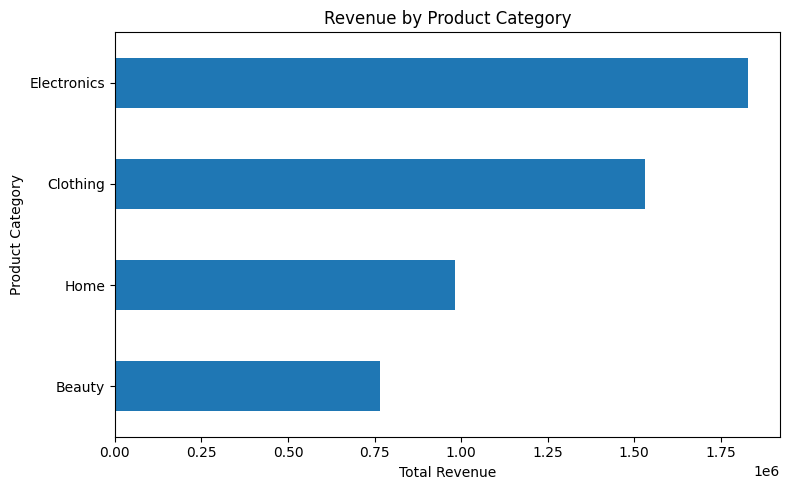

In [26]:
import matplotlib.pyplot as plt

category_sales["total_revenue"].sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Revenue by Product Category")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")
plt.tight_layout()

plt.savefig("../visualizations/revenue_by_category.png", dpi=300)
plt.show()

In [27]:
customer_orders = (
    df.groupby("customer_id")
      .agg(
          total_orders=("order_id", "nunique"),
          total_revenue=("revenue", "sum"),
          average_rating=("customer_rating", "mean"),
          average_delivery_days=("delivery_days", "mean")
    )
)

customer_orders.head()

,total_orders,total_revenue,average_rating,average_delivery_days
customer_id,,,,
1000,9,6905.58,2.633333,5.444444
1001,6,3959.74,2.666667,6.333333
1002,4,1579.67,3.800000,7.500000
1003,2,2304.44,3.000000,5.000000
1004,5,6073.85,2.320000,6.800000


In [28]:
customer_orders["customer_type"] = np.where(
    customer_orders["total_orders"] > 1,
    "Repeat Customer",
    "One-Time Customer"
)

customer_orders["customer_type"].value_counts()

customer_type
Repeat Customer      950
One-Time Customer     39
Name: count, dtype: int64

In [29]:
customer_summary = (
    customer_orders
    .groupby("customer_type")
    .agg(
        customers=("total_orders", "size"),
        total_revenue=("total_revenue", "sum"),
        average_revenue_per_customer=("total_revenue", "mean"),
        average_orders=("total_orders", "mean"),
        average_rating=("average_rating", "mean"),
        average_delivery_days=("average_delivery_days", "mean")
    )
)

customer_summary

,customers,total_revenue,average_revenue_per_customer,average_orders,average_rating,average_delivery_days
customer_type,,,,,,
One-Time Customer,39,36803.19,943.671538,1.000000,3.007692,6.307692
Repeat Customer,950,5072972.55,5339.971105,5.222105,2.966020,6.112208


In [30]:
customer_summary

,customers,total_revenue,average_revenue_per_customer,average_orders,average_rating,average_delivery_days
customer_type,,,,,,
One-Time Customer,39,36803.19,943.671538,1.000000,3.007692,6.307692
Repeat Customer,950,5072972.55,5339.971105,5.222105,2.966020,6.112208


In [31]:
delivery_rating = (
    df.groupby("delivery_days")
      .agg(
          orders=("order_id", "nunique"),
          average_rating=("customer_rating", "mean"),
          total_revenue=("revenue", "sum")
      )
      .sort_index()
)

delivery_rating

,orders,average_rating,total_revenue
delivery_days,,,
1,440,2.988636,429131.80
2,424,2.935849,434450.54
3,410,2.931463,403409.06
4,474,3.071308,515197.31
5,413,3.044310,404718.45
6,481,2.963617,505489.47
7,475,3.024632,501727.28
8,469,2.985501,481388.74
9,455,2.953846,469759.40


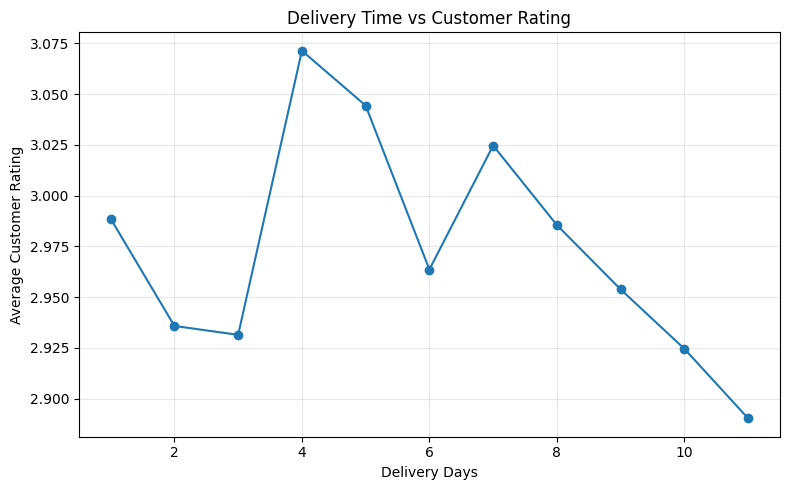

In [32]:
import matplotlib.pyplot as plt

delivery_rating["average_rating"].plot(
    kind="line",
    marker="o",
    figsize=(8, 5)
)

plt.title("Delivery Time vs Customer Rating")
plt.xlabel("Delivery Days")
plt.ylabel("Average Customer Rating")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("../visualizations/delivery_vs_rating.png", dpi=300)
plt.show()

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/ecommerce_sales_analytics_5000.csv")

df["order_date"] = pd.to_datetime(df["order_date"])

print("Data loaded:", df.shape)

Data loaded: (5000, 12)


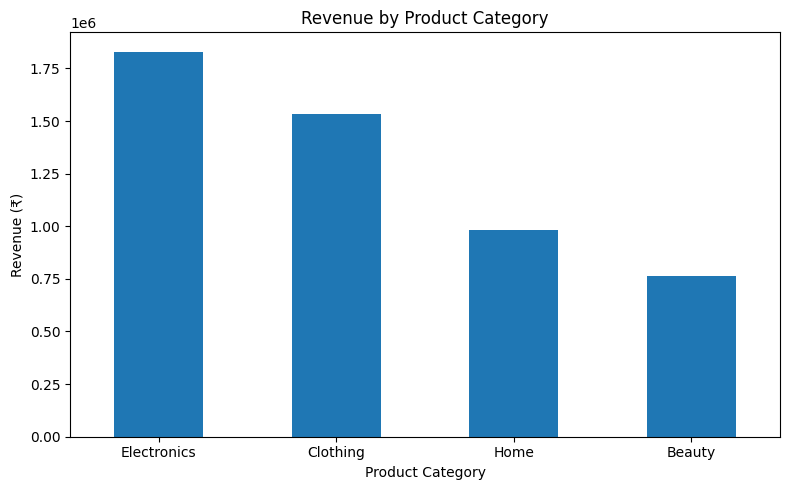

In [2]:
category_revenue = (
    df.groupby("product_category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
category_revenue.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../visualizations/revenue_by_category.png", dpi=300)
plt.show()

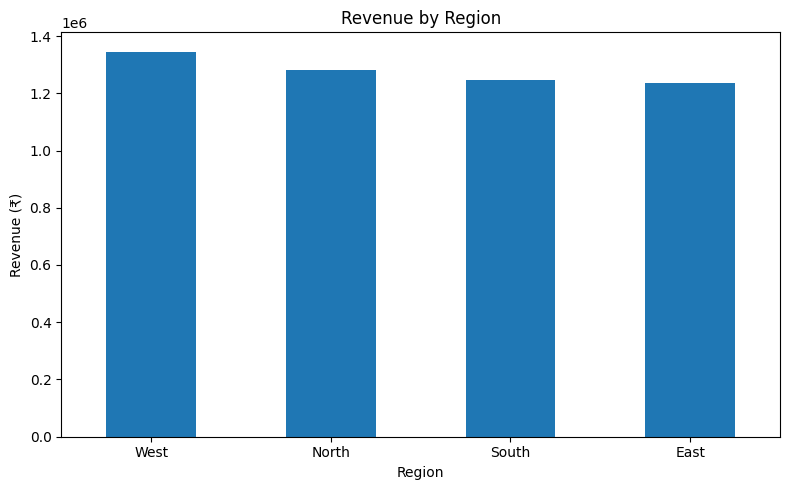

In [3]:
region_revenue = (
    df.groupby("region")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
region_revenue.plot(kind="bar")

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../visualizations/revenue_by_region.png", dpi=300)
plt.show()

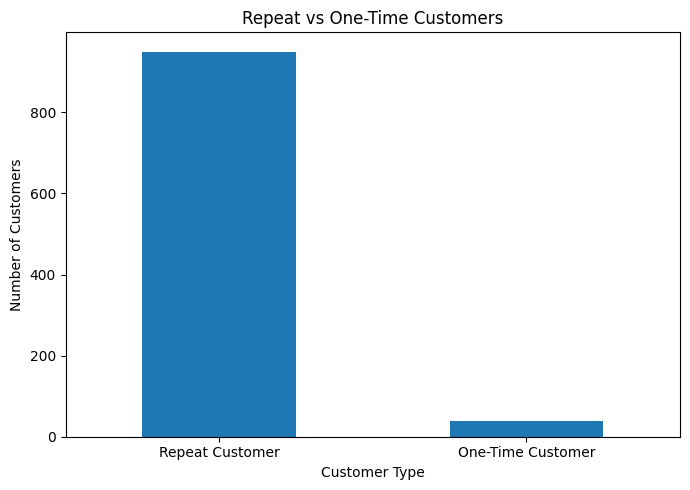

In [4]:
customer_orders = df.groupby("customer_id")["order_id"].nunique()

customer_type = customer_orders.apply(
    lambda x: "One-Time Customer" if x == 1 else "Repeat Customer"
)

customer_counts = customer_type.value_counts()

plt.figure(figsize=(7, 5))
customer_counts.plot(kind="bar")

plt.title("Repeat vs One-Time Customers")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../visualizations/customer_retention.png", dpi=300)
plt.show()

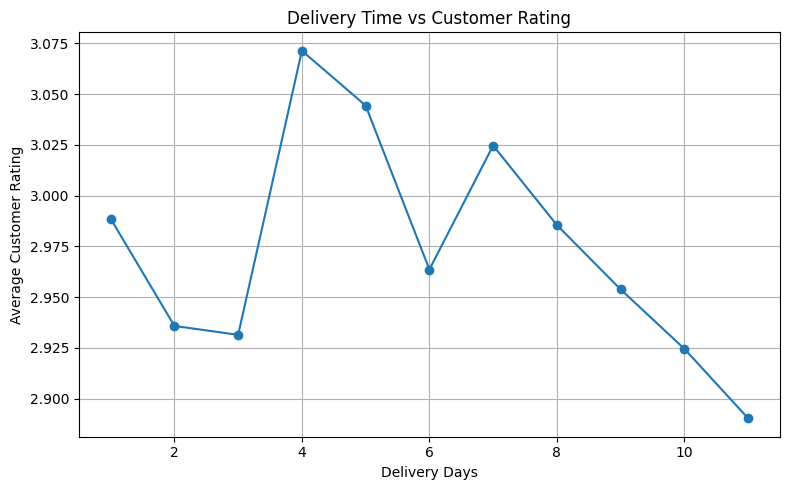

In [5]:
delivery_rating = (
    df.groupby("delivery_days")["customer_rating"]
    .mean()
)

plt.figure(figsize=(8, 5))
delivery_rating.plot(kind="line", marker="o")

plt.title("Delivery Time vs Customer Rating")
plt.xlabel("Delivery Days")
plt.ylabel("Average Customer Rating")
plt.grid(True)
plt.tight_layout()

plt.savefig("../visualizations/delivery_vs_rating.png", dpi=300)
plt.show()